In [1]:
import os, glob, json, time, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH = 32
OUT = "/kaggle/working"
print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU"))

TF: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [5]:
def find_split(name):
    for root, dirs, _ in os.walk("/kaggle/input"):
        if os.path.basename(root) == name and "glioma" in dirs:
            return root
    raise FileNotFoundError(name)

TRAIN_DIR = find_split("train")
VALID_DIR = find_split("valid")
TEST_DIR  = find_split("test")
print(TRAIN_DIR, VALID_DIR, TEST_DIR, sep="\n")

# keep only folders (skips the _classes.csv file Roboflow adds)
CLASSES = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
print("Classes:", CLASSES)

/kaggle/input/datasets/ankit20554/tumor-datsets/train-20260930T125139Z-1-001/train
/kaggle/input/datasets/ankit20554/tumor-datsets/valid-20260930T125114Z-1-001/valid
/kaggle/input/datasets/ankit20554/tumor-datsets/test-20260930T125144Z-1-001/test
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


split       test  train  valid
class                         
glioma        80    564    161
meningioma    63    358    124
no_tumor      49    335     99
pituitary     54    438    118


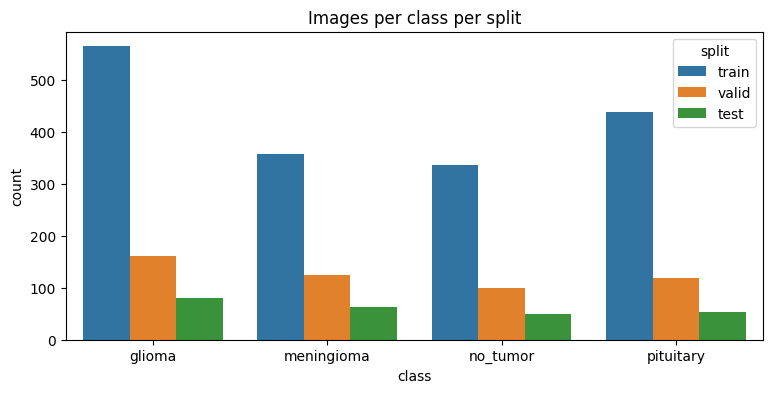

In [6]:
rows = []
for split, d in [("train", TRAIN_DIR), ("valid", VALID_DIR), ("test", TEST_DIR)]:
    for c in CLASSES:
        folder = os.path.join(d, c)
        n = len([f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
        rows.append({"split": split, "class": c, "count": n})

counts = pd.DataFrame(rows)
print(counts.pivot(index="class", columns="split", values="count"))

plt.figure(figsize=(9,4))
sns.barplot(data=counts, x="class", y="count", hue="split")
plt.title("Images per class per split")
plt.show()

Resolution/mode (sample of 300): {((640, 640), 'RGB'): 300}


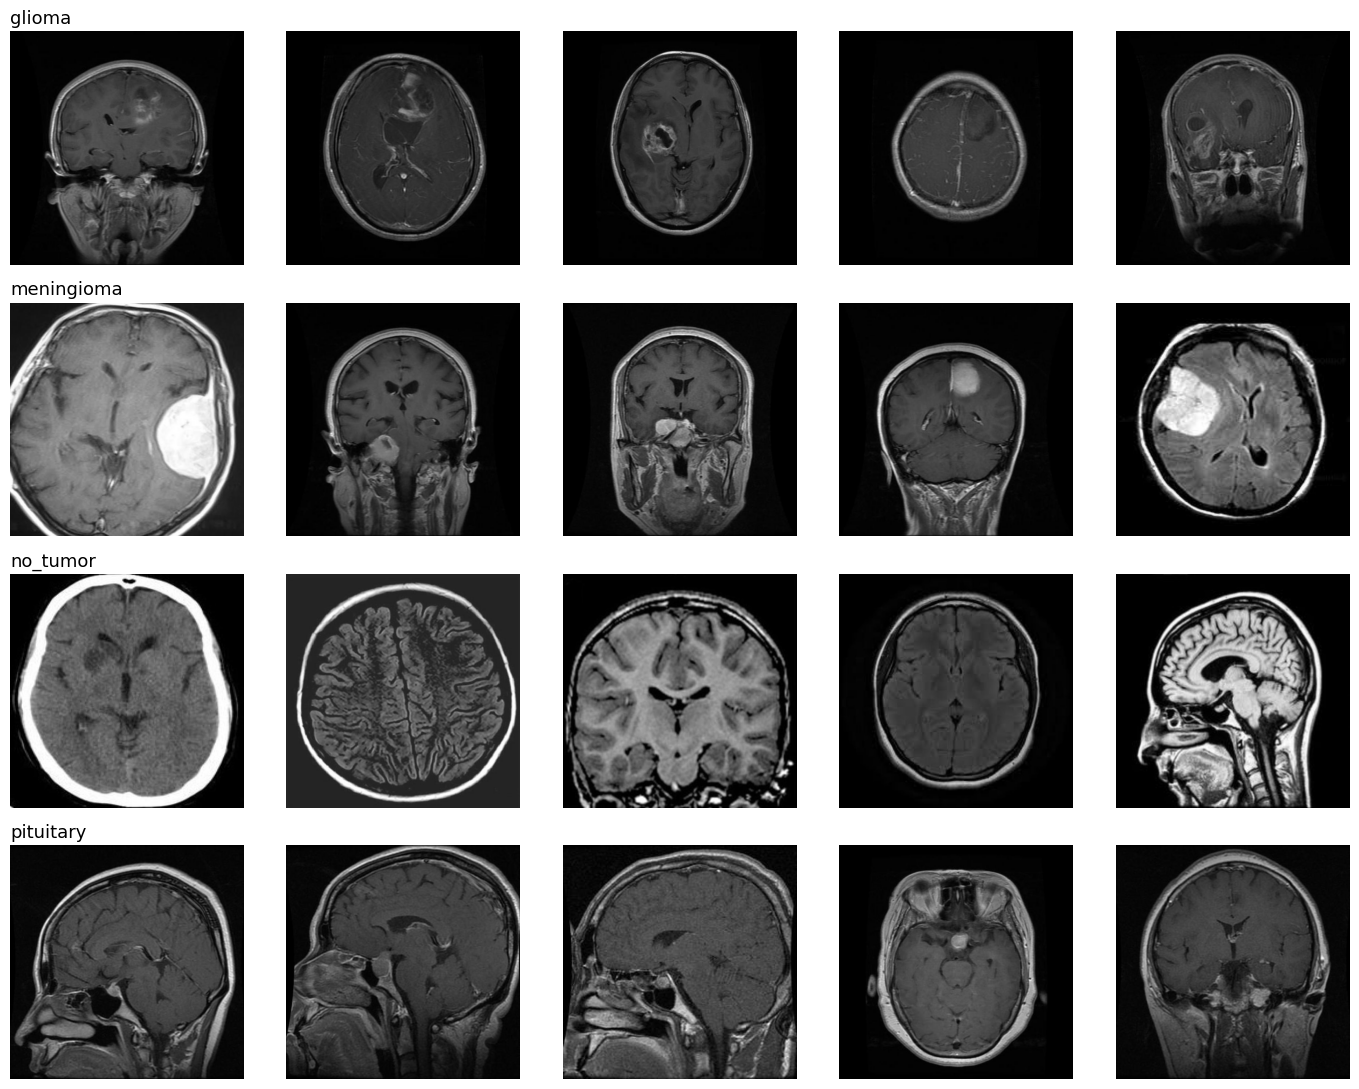

In [7]:
def list_images(folder):
    return [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

sizes = {}
for f in glob.glob(f"{TRAIN_DIR}/*/*.jpg")[:300]:
    im = Image.open(f)
    sizes[(im.size, im.mode)] = sizes.get((im.size, im.mode), 0) + 1
print("Resolution/mode (sample of 300):", sizes)

fig, axes = plt.subplots(len(CLASSES), 5, figsize=(14, 11))
for i, c in enumerate(CLASSES):
    files = random.sample(list_images(os.path.join(TRAIN_DIR, c)), 5)
    for j, f in enumerate(files):
        axes[i, j].imshow(Image.open(os.path.join(TRAIN_DIR, c, f)))
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_title(c, loc="left", fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
def load(d, shuffle):
    return keras.utils.image_dataset_from_directory(
        d, labels="inferred", label_mode="categorical", class_names=CLASSES,
        image_size=IMG_SIZE, batch_size=BATCH, shuffle=shuffle, seed=SEED)

train_raw = load(TRAIN_DIR, True)
valid_raw = load(VALID_DIR, False)
test_raw  = load(TEST_DIR, False)

Found 1695 files belonging to 4 classes.


I0000 00:00:1791307343.947881      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791307343.952079      49 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 502 files belonging to 4 classes.
Found 246 files belonging to 4 classes.


Class weights: {0: np.float64(0.7513297872340425), 1: np.float64(1.183659217877095), 2: np.float64(1.2649253731343284), 3: np.float64(0.9674657534246576)}


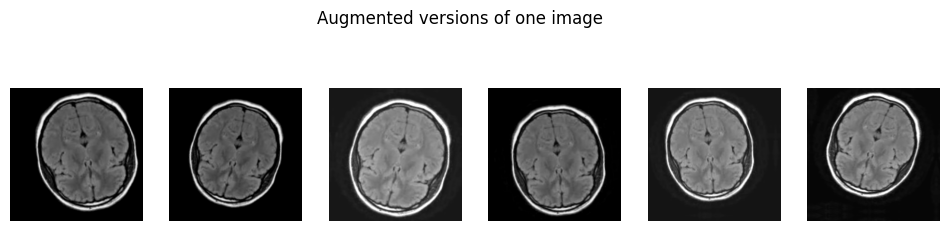

In [9]:
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomBrightness(0.15, value_range=(0, 255)),
    layers.RandomContrast(0.15),
], name="augmentation")

AUTO = tf.data.AUTOTUNE
train_ds = train_raw.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTO).prefetch(AUTO)
valid_ds = valid_raw.prefetch(AUTO)
test_ds  = test_raw.prefetch(AUTO)

y_train = np.concatenate([np.argmax(y, 1) for _, y in train_raw])
cw = compute_class_weight("balanced", classes=np.arange(len(CLASSES)), y=y_train)
CLASS_WEIGHT = dict(enumerate(cw))
print("Class weights:", CLASS_WEIGHT)

x, _ = next(iter(train_raw.take(1)))
plt.figure(figsize=(12,3))
for i in range(6):
    plt.subplot(1, 6, i+1)
    plt.imshow(augment(x[:1], training=True)[0].numpy().clip(0,255).astype("uint8"))
    plt.axis("off")
plt.suptitle("Augmented versions of one image")
plt.show()

In [13]:
def get_callbacks(name, patience=10):
    return [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience,
                                      restore_best_weights=True, start_from_epoch=5),
        keras.callbacks.ModelCheckpoint(f"{OUT}/{name}_best.keras", monitor="val_loss", save_best_only=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=4, min_lr=1e-6),
    ]

def plot_history(histories, title):
    acc, vacc, loss, vloss = [], [], [], []
    for h in histories:
        acc += h.history["accuracy"];  vacc += h.history["val_accuracy"]
        loss += h.history["loss"];     vloss += h.history["val_loss"]
    fig, ax = plt.subplots(1, 2, figsize=(13,4))
    ax[0].plot(acc, label="train"); ax[0].plot(vacc, label="val"); ax[0].set_title(f"{title} – Accuracy"); ax[0].legend()
    ax[1].plot(loss, label="train"); ax[1].plot(vloss, label="val"); ax[1].set_title(f"{title} – Loss"); ax[1].legend()
    plt.show()

y_test = np.concatenate([np.argmax(y, 1) for _, y in test_raw])
RESULTS = {}

def evaluate(model, name):
    t0 = time.time()
    probs = model.predict(test_ds, verbose=0)
    infer_ms = (time.time() - t0) / len(y_test) * 1000
    y_pred = probs.argmax(1)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")
    RESULTS[name] = {"accuracy": accuracy_score(y_test, y_pred), "precision": p, "recall": r,
                     "f1": f1, "params_M": model.count_params()/1e6, "ms_per_image": infer_ms}
    print(classification_report(y_test, y_pred, target_names=CLASSES, digits=4))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(f"{name} – Confusion Matrix")
    plt.show()

In [14]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x); x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    return layers.Dropout(0.2)(x)

def build_custom_cnn():
    inp = keras.Input(shape=IMG_SIZE + (3,))
    x = layers.Rescaling(1./255)(inp)
    for f in [32, 64, 128, 256]:
        x = conv_block(x, f)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(len(CLASSES), activation="softmax")(x)
    return keras.Model(inp, out, name="custom_cnn")

cnn = build_custom_cnn()
cnn.compile(optimizer=keras.optimizers.Adam(5e-4), loss="categorical_crossentropy", metrics=["accuracy"])
cnn.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,241,956 (4.74 MB)

 Trainable params: 1,240,036 (4.73 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 446ms/step - accuracy: 0.5563 - loss: 1.1032 - val_accuracy: 0.3904 - val_loss: 1.3060 - learning_rate: 5.0000e-04
Epoch 2/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 260ms/step - accuracy: 0.6425 - loss: 0.9421 - val_accuracy: 0.5558 - val_loss: 0.9250 - learning_rate: 5.0000e-04
Epoch 3/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 265ms/step - accuracy: 0.6791 - loss: 0.8482 - val_accuracy: 0.6853 - val_loss: 0.7860 - learning_rate: 5.0000e-04
Epoch 4/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 255ms/step - accuracy: 0.6773 - loss: 0.8132 - val_accuracy: 0.2291 - val_loss: 5.8803 - learning_rate: 5.0000e-04
Epoch 5/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 259ms/step - accuracy: 0.7174 - loss: 0.7541 - val_accuracy: 0.5896 - val_loss: 1.2186 - learning_rate: 5.0000e-04
Epoch 6/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 259ms/step - accuracy: 0.7268 - loss: 0.7085 - val_accuracy: 0.5916 - val_loss: 0.9534 - learning_rate: 5.0000e-04
Epoch 7/40
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 256ms/step - acc

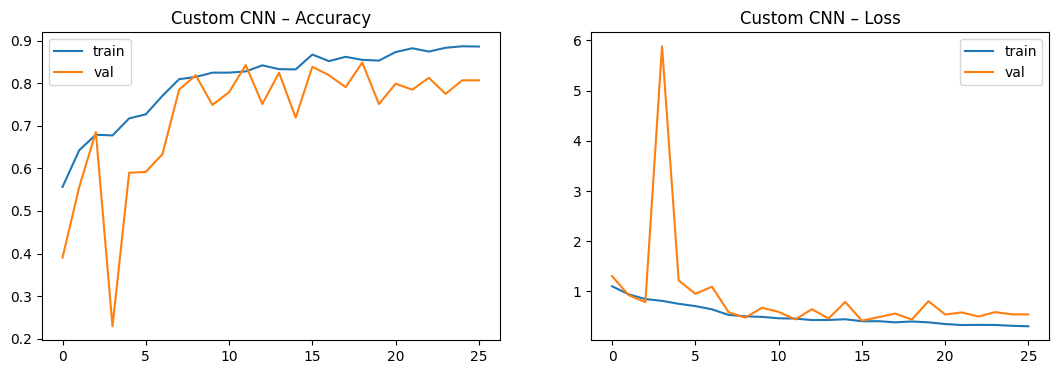

              precision    recall  f1-score   support

      glioma     0.7980    0.9875    0.8827        80
  meningioma     0.8372    0.5714    0.6792        63
    no_tumor     0.8261    0.7755    0.8000        49
   pituitary     0.8621    0.9259    0.8929        54

    accuracy                         0.8252       246
   macro avg     0.8308    0.8151    0.8137       246
weighted avg     0.8277    0.8252    0.8163       246



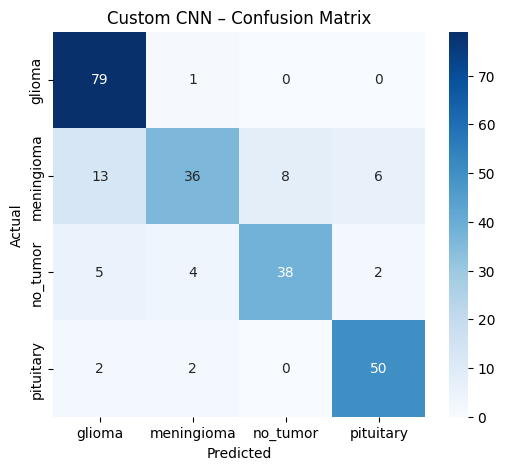

In [17]:
h_cnn = cnn.fit(train_ds, validation_data=valid_ds, epochs=40,
                class_weight=CLASS_WEIGHT, callbacks=get_callbacks("custom_cnn"))
plot_history([h_cnn], "Custom CNN")
evaluate(cnn, "Custom CNN")
cnn.save(f"{OUT}/custom_cnn.h5")

In [18]:
def build_transfer(base_fn, preprocess_layer, name):
    base = base_fn(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
    base.trainable = False
    inp = keras.Input(shape=IMG_SIZE + (3,))
    x = preprocess_layer(inp) if preprocess_layer else inp
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(len(CLASSES), activation="softmax")(x)
    return keras.Model(inp, out, name=name), base

def train_transfer(model, base, name, unfreeze_last=40):
    # Phase 1: train only the new head (base frozen)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
    h1 = model.fit(train_ds, validation_data=valid_ds, epochs=15,
                   class_weight=CLASS_WEIGHT, callbacks=get_callbacks(name))
    # Phase 2: fine-tune the top layers of the base model
    base.trainable = True
    for layer in base.layers[:-unfreeze_last]:
        layer.trainable = False
    for layer in base.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    model.compile(optimizer=keras.optimizers.Adam(1e-5), loss="categorical_crossentropy", metrics=["accuracy"])
    h2 = model.fit(train_ds, validation_data=valid_ds, epochs=25,
                   class_weight=CLASS_WEIGHT, callbacks=get_callbacks(name))
    plot_history([h1, h2], name)
    return model

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15


2026-10-06 17:40:21.209613: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 17:40:21.347740: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


51/53 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.6680 - loss: 1.0021

2026-10-06 17:40:44.492281: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 17:40:44.646921: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 17:40:44.785168: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.6718 - loss: 0.9915

2026-10-06 17:41:02.549926: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 17:41:02.688054: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


53/53 ━━━━━━━━━━━━━━━━━━━━ 63s 790ms/step - accuracy: 0.7670 - loss: 0.7211 - val_accuracy: 0.7829 - val_loss: 0.7903 - learning_rate: 0.0010
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 256ms/step - accuracy: 0.8602 - loss: 0.4294 - val_accuracy: 0.8466 - val_loss: 0.6059 - learning_rate: 0.0010
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 243ms/step - accuracy: 0.8962 - loss: 0.3083 - val_accuracy: 0.8227 - val_loss: 0.7062 - learning_rate: 0.0010
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 250ms/step - accuracy: 0.8956 - loss: 0.3103 - val_accuracy: 0.7869 - val_loss: 0.7768 - learning_rate: 0.0010
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 245ms/step - accuracy: 0.9180 - loss: 0.2238 - val_accuracy: 0.8406 - val_loss: 0.6280 - learning_rate: 0.0010
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 259ms/step - accuracy: 0.9245 - loss: 0.2206 - val_accuracy: 0.8207 - val_loss: 0.7166 - learning_rate: 0.0010
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 266ms/step - accuracy: 0.9363 - loss: 0.1842 - val_

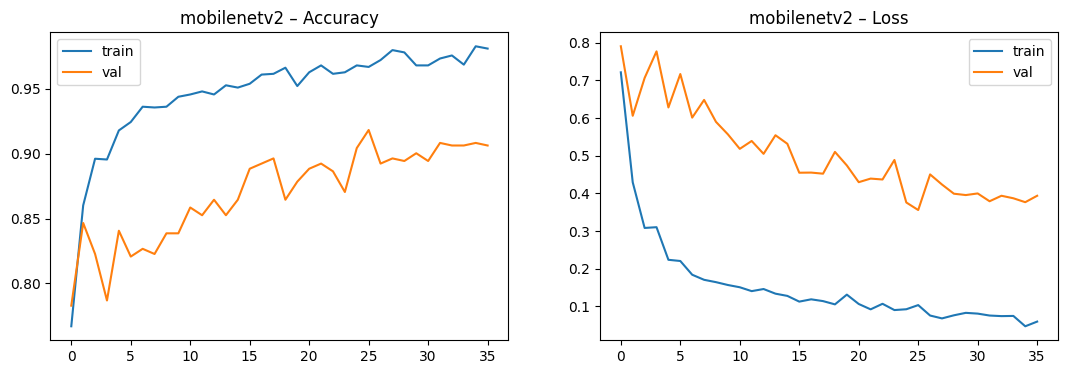

              precision    recall  f1-score   support

      glioma     0.9474    0.9000    0.9231        80
  meningioma     0.8226    0.8095    0.8160        63
    no_tumor     0.9545    0.8571    0.9032        49
   pituitary     0.8438    1.0000    0.9153        54

    accuracy                         0.8902       246
   macro avg     0.8921    0.8917    0.8894       246
weighted avg     0.8941    0.8902    0.8900       246



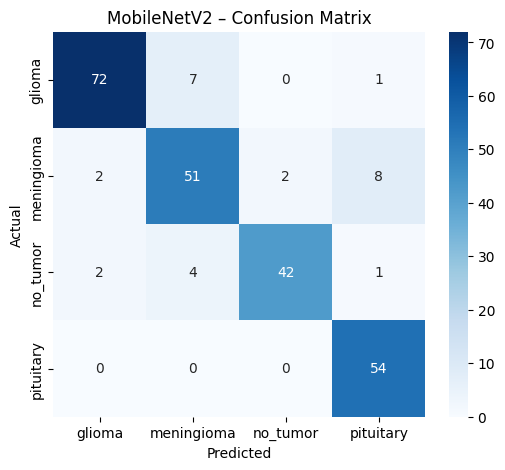

In [19]:
mnet, mnet_base = build_transfer(keras.applications.MobileNetV2,
                                 layers.Rescaling(1./127.5, offset=-1), "mobilenetv2")
mnet = train_transfer(mnet, mnet_base, "mobilenetv2", unfreeze_last=40)
evaluate(mnet, "MobileNetV2")
mnet.save(f"{OUT}/mobilenetv2.h5")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15


2026-10-06 17:51:18.692857: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 17:51:18.837961: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 17:51:19.208121: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 17:51:19.351901: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 17:51:20.197231: E external/local_xla/xla/stream_

52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.6680 - loss: 0.9909

2026-10-06 17:51:42.963486: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 17:51:43.108202: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 17:51:43.463057: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 17:51:43.608300: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 17:51:43.752079: E external/local_xla/xla/stream_

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.6695 - loss: 0.9870

2026-10-06 17:52:03.012270: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 17:52:03.154441: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 17:52:03.505069: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 17:52:03.648966: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-06 17:52:04.482430: E external/local_xla/xla/stream_

53/53 ━━━━━━━━━━━━━━━━━━━━ 68s 791ms/step - accuracy: 0.7487 - loss: 0.7866 - val_accuracy: 0.7669 - val_loss: 0.7480 - learning_rate: 0.0010
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 254ms/step - accuracy: 0.8401 - loss: 0.4876 - val_accuracy: 0.7849 - val_loss: 0.7135 - learning_rate: 0.0010
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 254ms/step - accuracy: 0.8643 - loss: 0.4020 - val_accuracy: 0.8048 - val_loss: 0.6288 - learning_rate: 0.0010
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 241ms/step - accuracy: 0.8838 - loss: 0.3494 - val_accuracy: 0.8247 - val_loss: 0.6523 - learning_rate: 0.0010
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 241ms/step - accuracy: 0.9062 - loss: 0.2894 - val_accuracy: 0.8127 - val_loss: 0.7042 - learning_rate: 0.0010
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 258ms/step - accuracy: 0.9027 - loss: 0.2713 - val_accuracy: 0.8566 - val_loss: 0.5663 - learning_rate: 0.0010
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 242ms/step - accuracy: 0.9127 - loss: 0.2379 - val_

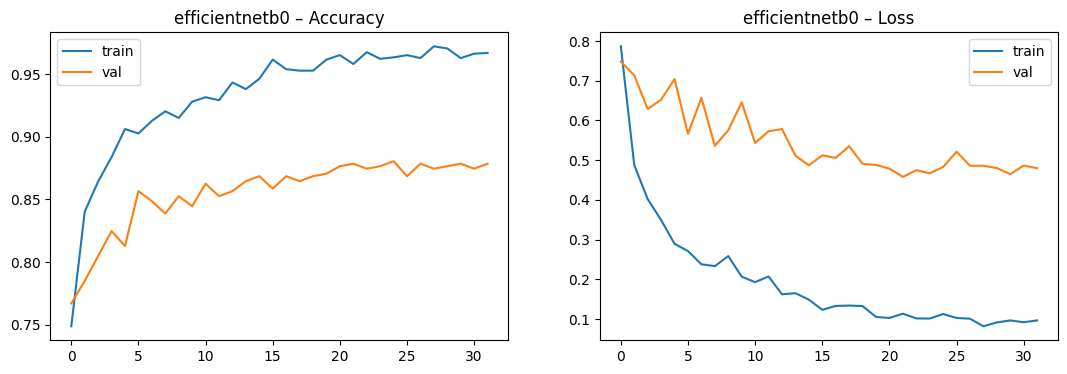

              precision    recall  f1-score   support

      glioma     0.9024    0.9250    0.9136        80
  meningioma     0.8958    0.6825    0.7748        63
    no_tumor     0.9318    0.8367    0.8817        49
   pituitary     0.7500    1.0000    0.8571        54

    accuracy                         0.8618       246
   macro avg     0.8700    0.8611    0.8568       246
weighted avg     0.8731    0.8618    0.8593       246



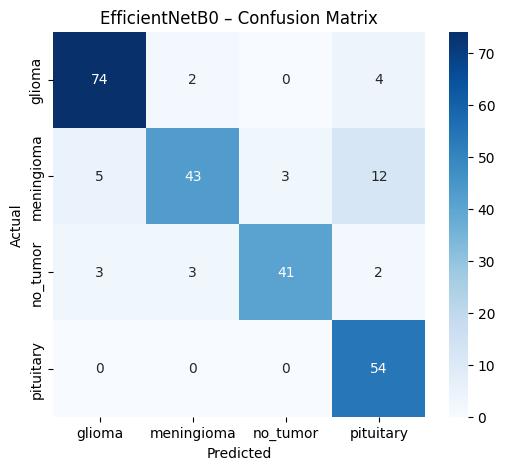

In [20]:
effnet, eff_base = build_transfer(keras.applications.EfficientNetB0, None, "efficientnetb0")
effnet = train_transfer(effnet, eff_base, "efficientnetb0", unfreeze_last=60)
evaluate(effnet, "EfficientNetB0")
effnet.save(f"{OUT}/efficientnetb0.h5")

custom_cnn 15.0 MB
mobilenetv2 26.7 MB
efficientnetb0 41.9 MB


,accuracy,precision,recall,f1,params_M,ms_per_image
MobileNetV2,0.8902,0.8921,0.8917,0.8894,2.5921,38.7432
EfficientNetB0,0.8618,0.8700,0.8611,0.8568,4.3837,54.0031
Custom CNN,0.8252,0.8308,0.8151,0.8137,1.2420,8.8043


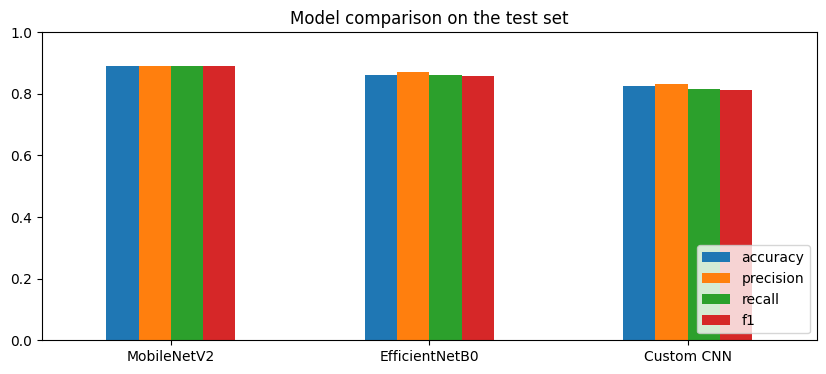

Best model: MobileNetV2


In [21]:
for f in ["custom_cnn", "mobilenetv2", "efficientnetb0"]:
    p = f"{OUT}/{f}.h5"
    if os.path.exists(p):
        print(f, round(os.path.getsize(p)/1e6, 1), "MB")

cmp = pd.DataFrame(RESULTS).T.round(4).sort_values("f1", ascending=False)
display(cmp)
cmp.to_csv(f"{OUT}/model_comparison.csv")

cmp[["accuracy", "precision", "recall", "f1"]].plot(kind="bar", figsize=(10,4), ylim=(0,1))
plt.title("Model comparison on the test set"); plt.xticks(rotation=0); plt.legend(loc="lower right")
plt.show()

BEST = cmp.index[0]
print("Best model:", BEST)

In [27]:
best_model = {"Custom CNN": cnn, "MobileNetV2": mnet, "EfficientNetB0": effnet}[BEST]
best_model.save(f"{OUT}/best_model.keras")
best_model.save(f"{OUT}/best_model.h5")
json.dump({"classes": CLASSES, "best_model": BEST, "img_size": list(IMG_SIZE)},
          open(f"{OUT}/class_names.json", "w"))
print("TensorFlow version for requirements.txt:", tf.__version__)
!cd /kaggle/working && zip -q outputs.zip *.h5 *.keras *.json *.csv && ls -lh

TensorFlow version for requirements.txt: 2.20.0
total 404M
-rw-r--r-- 1 root root  26M Oct  6 18:08 best_model.h5
-rw-r--r-- 1 root root  26M Oct  6 18:08 best_model.keras
-rw-r--r-- 1 root root  115 Oct  6 18:08 class_names.json
-rw-r--r-- 1 root root  15M Oct  6 17:34 custom_cnn_best.keras
-rw-r--r-- 1 root root  15M Oct  6 17:36 custom_cnn.h5
-rw-r--r-- 1 root root  41M Oct  6 17:58 efficientnetb0_best.keras
-rw-r--r-- 1 root root  40M Oct  6 18:01 efficientnetb0.h5
-rw-r--r-- 1 root root  26M Oct  6 17:48 mobilenetv2_best.keras
-rw-r--r-- 1 root root  26M Oct  6 17:50 mobilenetv2.h5
-rw-r--r-- 1 root root  140 Oct  6 18:07 model_comparison_clean_test.csv
-rw-r--r-- 1 root root  215 Oct  6 18:01 model_comparison.csv
-rw-r--r-- 1 root root 193M Oct  6 18:08 outputs.zip


In [28]:
 import zipfile
with zipfile.ZipFile(f"{OUT}/outputs.zip", "w") as z:
    for f in os.listdir(OUT):
        if f.endswith((".h5", ".keras", ".json", ".csv")):
            z.write(os.path.join(OUT, f), f)
            print("Added:", f)
print(round(os.path.getsize(f"{OUT}/outputs.zip")/1e6, 1), "MB")

Added: efficientnetb0.h5
Added: custom_cnn_best.keras
Added: mobilenetv2_best.keras
Added: mobilenetv2.h5
Added: class_names.json
Added: custom_cnn.h5
Added: efficientnetb0_best.keras
Added: model_comparison_clean_test.csv
Added: model_comparison.csv
Added: best_model.h5
Added: best_model.keras
221.5 MB


In [24]:
import zipfile, tempfile

zip_path = f"{OUT}/outputs.zip"
with zipfile.ZipFile(zip_path) as z:
    in_zip = set(z.namelist())
    print("Zip test (corrupt files):", z.testzip() or "None, zip is OK")

in_folder = {f for f in os.listdir(OUT) if os.path.isfile(os.path.join(OUT, f)) and f != "outputs.zip"}

print("\nFiles in zip:", len(in_zip))
for f in sorted(in_zip):
    print("  ✅", f)

missing = in_folder - in_zip
print("\nMissing from zip:", missing if missing else "Nothing, all files are included")

# check that the best model inside the zip actually loads and predicts
with tempfile.TemporaryDirectory() as tmp:
    with zipfile.ZipFile(zip_path) as z:
        z.extract("best_model.keras", tmp)
        z.extract("class_names.json", tmp)
    m = keras.models.load_model(f"{tmp}/best_model.keras")
    meta = json.load(open(f"{tmp}/class_names.json"))
    acc = accuracy_score(y_test, m.predict(test_ds, verbose=0).argmax(1))
    print("\nLoaded model from zip:", meta["best_model"], "| classes:", meta["classes"])
    print("Test accuracy of zipped model:", round(acc, 4))

Zip test (corrupt files): None, zip is OK

Files in zip: 10
  ✅ best_model.h5
  ✅ best_model.keras
  ✅ class_names.json
  ✅ custom_cnn.h5
  ✅ custom_cnn_best.keras
  ✅ efficientnetb0.h5
  ✅ efficientnetb0_best.keras
  ✅ mobilenetv2.h5
  ✅ mobilenetv2_best.keras
  ✅ model_comparison.csv

Missing from zip: Nothing, all files are included


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 21 variables whereas the saved optimizer has 40 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Loaded model from zip: MobileNetV2 | classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Test accuracy of zipped model: 0.8902


In [25]:
import re
def base_ids(d):
    return {re.sub(r"_jpg\.rf\..*", "", f) for c in CLASSES for f in os.listdir(os.path.join(d, c))}

tr, va, te = base_ids(TRAIN_DIR), base_ids(VALID_DIR), base_ids(TEST_DIR)
print("Train-Test overlap :", len(tr & te))
print("Train-Valid overlap:", len(tr & va))
print("Valid-Test overlap :", len(va & te))

Train-Test overlap : 57
Train-Valid overlap: 97
Valid-Test overlap : 10


In [26]:
# Re-evaluate all 3 models on only the leakage-free test images
seen = tr | va
test_files = test_raw.file_paths   # same order as y_test (shuffle=False)
clean_mask = np.array([re.sub(r"_jpg\.rf\..*", "", os.path.basename(f)) not in seen for f in test_files])
print(f"Clean test images: {clean_mask.sum()} / {len(clean_mask)}")

clean_rows = {}
for name, m in {"Custom CNN": cnn, "MobileNetV2": mnet, "EfficientNetB0": effnet}.items():
    y_pred = m.predict(test_ds, verbose=0).argmax(1)
    yt, yp = y_test[clean_mask], y_pred[clean_mask]
    p, r, f1, _ = precision_recall_fscore_support(yt, yp, average="macro", zero_division=0)
    clean_rows[name] = {"full_test_acc": RESULTS[name]["accuracy"],
                        "clean_test_acc": accuracy_score(yt, yp), "clean_f1": f1}

clean_cmp = pd.DataFrame(clean_rows).T.round(4).sort_values("clean_f1", ascending=False)
display(clean_cmp)
clean_cmp.to_csv(f"{OUT}/model_comparison_clean_test.csv")

Clean test images: 179 / 246


,full_test_acc,clean_test_acc,clean_f1
MobileNetV2,0.8902,0.8939,0.8893
EfficientNetB0,0.8618,0.8436,0.8302
Custom CNN,0.8252,0.7654,0.7359
